# 09 Final Model Selection and Interpretation

This notebook provides the final model selection and interpretation stage for the building energy efficiency prediction project. It consolidates all modeling results from the previous notebooks and identifies the most suitable final models for predicting **Heating Load** and **Cooling Load**.

The final decision is based on predictive accuracy, generalization performance, model-family comparison, feature importance, and practical interpretability for building energy efficiency analysis.

## Notebook Objectives

This final notebook aims to:

1. Load and consolidate model results from all modeling stages.
2. Rank models separately for Heating Load and Cooling Load.
3. Compare model families: parametric, regularized, semi-parametric, nonlinear machine learning, and deep learning.
4. Identify the final recommended model for each response variable.
5. Interpret the most important predictors using permutation importance results.
6. Produce final tables and visuals suitable for the project report and presentation.
7. Save final model-selection outputs.

In [1]:
# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:.6f}")

In [2]:
# ============================================================
# 2. DEFINE PROJECT PATHS
# ============================================================

MODEL_OUTPUT_DIR = Path("../outputs/models")

if not MODEL_OUTPUT_DIR.exists():
    MODEL_OUTPUT_DIR = Path("outputs/models")

FINAL_OUTPUT_DIR = Path("../outputs/final_selection")

if not FINAL_OUTPUT_DIR.exists():
    FINAL_OUTPUT_DIR = Path("outputs/final_selection")

FINAL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Model output directory:", MODEL_OUTPUT_DIR.resolve())
print("Final output directory:", FINAL_OUTPUT_DIR.resolve())

Model output directory: C:\Users\admin\Desktop\pppp lab\group-work\outputs\models
Final output directory: C:\Users\admin\Desktop\pppp lab\group-work\full\outputs\final_selection


# 1. Load Model Results

The project generated several model-result files across the previous notebooks. This section loads all available result files and combines them into one master comparison table. Missing files are skipped so the notebook can still run even if some optional models, such as deep learning, were not executed.

In [3]:
# ============================================================
# 3. LOAD ALL AVAILABLE MODEL RESULT FILES
# ============================================================

result_files = {
    "Parametric OLS": "parametric_ols_results.csv",
    "Regularized Regression": "regularized_regression_results.csv",
    "Semi-Parametric and Nonlinear": "semi_parametric_nonlinear_model_results.csv",
    "Deep Learning": "deep_learning_model_results.csv",
    "Deep Learning Comparison": "deep_learning_vs_previous_best.csv"
}

loaded_results = []

for source_name, file_name in result_files.items():
    file_path = MODEL_OUTPUT_DIR / file_name

    if file_path.exists():
        temp_df = pd.read_csv(file_path)
        temp_df["Source_Notebook"] = source_name
        loaded_results.append(temp_df)
        print(f"Loaded: {file_name}")
    else:
        print(f"Skipped missing file: {file_name}")

if len(loaded_results) == 0:
    raise FileNotFoundError(
        "No model result files were found. Ensure previous notebooks saved model results in outputs/models."
    )

all_results_raw = pd.concat(loaded_results, ignore_index=True)

print("Raw combined results shape:", all_results_raw.shape)
display(all_results_raw.head())

Loaded: parametric_ols_results.csv
Loaded: regularized_regression_results.csv
Loaded: semi_parametric_nonlinear_model_results.csv
Loaded: deep_learning_model_results.csv
Loaded: deep_learning_vs_previous_best.csv
Raw combined results shape: (56, 14)


,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Heating Load,Parametric OLS (Forward Selection),6.000000,0.917052,0.916232,0.912213,0.908630,3.024936,2.184008,10.272485,3061.098454,3092.038419,Parametric OLS,NaN
1,Cooling Load,Parametric OLS (Forward Selection),5.000000,0.885850,0.884911,0.892570,0.888940,3.155028,2.201210,8.496013,3182.480788,3209.000758,Parametric OLS,NaN
2,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,NaN
3,Cooling Load,Elastic Net Regression,NaN,0.888202,NaN,0.894576,0.883958,3.125425,2.178830,NaN,NaN,NaN,Regularized Regression,NaN
4,Cooling Load,Ridge Regression,NaN,0.888174,NaN,0.894529,0.883906,3.126126,2.180461,NaN,NaN,NaN,Regularized Regression,NaN


In [4]:
# ============================================================
# 4. STANDARDIZE MODEL RESULT TABLE
# ============================================================

required_columns = [
    "Target",
    "Model",
    "Train_R2",
    "Test_R2",
    "Test_Adjusted_R2",
    "Test_RMSE",
    "Test_MAE"
]

missing_required = [col for col in required_columns if col not in all_results_raw.columns]

if missing_required:
    raise ValueError(f"The following required columns are missing: {missing_required}")

all_results = all_results_raw.copy()

# Compute train-test gap if missing or partially missing
if "Train_Test_R2_Gap" not in all_results.columns:
    all_results["Train_Test_R2_Gap"] = all_results["Train_R2"] - all_results["Test_R2"]
else:
    all_results["Train_Test_R2_Gap"] = all_results["Train_Test_R2_Gap"].fillna(
        all_results["Train_R2"] - all_results["Test_R2"]
    )

# Remove exact duplicates caused by comparison files
dedupe_cols = [
    "Target",
    "Model",
    "Train_R2",
    "Test_R2",
    "Test_RMSE",
    "Test_MAE"
]

all_results = (
    all_results
    .drop_duplicates(subset=dedupe_cols)
    .reset_index(drop=True)
)

print("Cleaned combined results shape:", all_results.shape)
display(all_results.head())

Cleaned combined results shape: (50, 14)


,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Heating Load,Parametric OLS (Forward Selection),6.000000,0.917052,0.916232,0.912213,0.908630,3.024936,2.184008,10.272485,3061.098454,3092.038419,Parametric OLS,0.004839
1,Cooling Load,Parametric OLS (Forward Selection),5.000000,0.885850,0.884911,0.892570,0.888940,3.155028,2.201210,8.496013,3182.480788,3209.000758,Parametric OLS,-0.006720
2,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,-0.006389
3,Cooling Load,Elastic Net Regression,NaN,0.888202,NaN,0.894576,0.883958,3.125425,2.178830,NaN,NaN,NaN,Regularized Regression,-0.006375
4,Cooling Load,Ridge Regression,NaN,0.888174,NaN,0.894529,0.883906,3.126126,2.180461,NaN,NaN,NaN,Regularized Regression,-0.006355


# 2. Master Model Comparison

The master comparison table ranks all fitted models by test \(R^2\). Error metrics such as RMSE and MAE are used to support the model-selection decision, while the train-test gap is used to assess generalization and overfitting.

In [5]:
# ============================================================
# 5. MASTER MODEL COMPARISON TABLE
# ============================================================

master_comparison = (
    all_results
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .reset_index(drop=True)
)

display(master_comparison)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning Comparison,0.008258
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008381
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.016055
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.007554
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.006143
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005207
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005348
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005354
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005506


In [6]:
# ============================================================
# 6. RANK MODELS BY TARGET
# ============================================================

ranked_models = master_comparison.copy()

ranked_models["Rank"] = (
    ranked_models
    .groupby("Target")["Test_R2"]
    .rank(method="dense", ascending=False)
    .astype(int)
)

ranked_models = ranked_models.sort_values(["Target", "Rank"])

display(ranked_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258,1
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning Comparison,0.008258,2
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008381,3
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.016055,4
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.007554,5
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.006143,6
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005207,7
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005348,8
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005354,9
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005506,10


In [7]:
# ============================================================
# 7. TOP MODELS PER TARGET
# ============================================================

top_n = 10

top_models = (
    ranked_models
    .groupby("Target")
    .head(top_n)
    .reset_index(drop=True)
)

display(top_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258,1
1,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Deep Learning Comparison,0.008258,2
2,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008381,3
3,Cooling Load,Support Vector Regression,NaN,0.990364,NaN,0.974309,0.972892,1.542869,1.015510,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.016055,4
4,Cooling Load,Gradient Boosting Regression,NaN,0.981211,NaN,0.973657,0.972203,1.562337,1.069845,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.007554,5
5,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.006143,6
6,Cooling Load,GAM-style Additive Model (n_knots=10),NaN,0.968454,NaN,0.963247,0.961219,1.845393,1.364645,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005207,7
7,Cooling Load,Smoothing Spline Model,NaN,0.968471,NaN,0.963123,0.961088,1.848494,1.366785,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005348,8
8,Cooling Load,GAM-style Additive Model (n_knots=8),NaN,0.968472,NaN,0.963119,0.961084,1.848602,1.366870,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005354,9
9,Cooling Load,GAM-style Additive Model (n_knots=6),NaN,0.968488,NaN,0.962982,0.960939,1.852028,1.369301,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.005506,10


In [8]:
# ============================================================
# 8. BEST MODEL PER TARGET
# ============================================================

best_models = (
    ranked_models
    .sort_values(["Target", "Test_R2"], ascending=[True, False])
    .groupby("Target")
    .head(1)
    .reset_index(drop=True)
)

display(best_models)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258,1
1,Heating Load,Tuned Gradient Boosting Regression,NaN,0.999499,NaN,0.998602,0.998525,0.381722,0.275321,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.000897,1


# 3. Model Family Classification

To make the final comparison easier to interpret, each model is grouped into a broad family: linear/parametric, regularized regression, semi-parametric/basis-function, nonlinear machine learning, or deep learning.

In [9]:
# ============================================================
# 9. ASSIGN MODEL FAMILIES
# ============================================================

def assign_model_family(model_name):
    name = str(model_name).lower()

    if "ridge" in name or "lasso" in name or "elastic" in name:
        return "Regularized Regression"

    if "ols" in name or "linear basis" in name:
        return "Linear / Parametric"

    if (
        "polynomial" in name
        or "spline" in name
        or "gam" in name
        or "step" in name
    ):
        return "Semi-Parametric / Basis Function"

    if (
        "gradient boosting" in name
        or "random forest" in name
        or "extra trees" in name
        or "support vector" in name
    ):
        return "Nonlinear Machine Learning"

    if (
        "ann" in name
        or "neural" in name
        or "deep" in name
    ):
        return "Deep Learning"

    return "Other"


model_family_results = all_results.copy()
model_family_results["Model_Family"] = model_family_results["Model"].apply(assign_model_family)

best_by_family = (
    model_family_results
    .sort_values(["Target", "Model_Family", "Test_R2"], ascending=[True, True, False])
    .groupby(["Target", "Model_Family"])
    .head(1)
    .reset_index(drop=True)
)

display(best_by_family.sort_values(["Target", "Test_R2"], ascending=[True, False]))

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Model_Family
2,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258,Nonlinear Machine Learning
0,Cooling Load,Neural Network Regression,NaN,0.991975,NaN,0.983595,0.982689,1.232919,0.874873,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008381,Deep Learning
4,Cooling Load,Polynomial Function Model,NaN,0.971237,NaN,0.965094,0.963168,1.798407,1.328792,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.006143,Semi-Parametric / Basis Function
1,Cooling Load,Linear Basis Model,NaN,0.888259,NaN,0.894958,0.889163,3.119755,2.180512,NaN,NaN,NaN,Semi-Parametric and Nonlinear,-0.006699,Linear / Parametric
3,Cooling Load,LASSO Regression,NaN,0.888211,NaN,0.894600,0.883984,3.125076,2.179070,NaN,NaN,NaN,Regularized Regression,-0.006389,Regularized Regression
7,Heating Load,Tuned Gradient Boosting Regression,NaN,0.999499,NaN,0.998602,0.998525,0.381722,0.275321,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.000897,Nonlinear Machine Learning
5,Heating Load,Simple ANN,NaN,0.998854,NaN,0.996633,0.996294,0.592402,0.432342,NaN,NaN,NaN,Deep Learning,0.002221,Deep Learning
9,Heating Load,Polynomial Function Model,NaN,0.996653,NaN,0.996392,0.996193,0.613233,0.504129,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.000261,Semi-Parametric / Basis Function
6,Heating Load,Linear Basis Model,NaN,0.924157,NaN,0.920850,0.916483,2.872277,2.059036,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.003307,Linear / Parametric
8,Heating Load,Elastic Net Regression,NaN,0.924135,NaN,0.920551,0.912549,2.877706,2.062607,NaN,NaN,NaN,Regularized Regression,0.003584,Regularized Regression


# 4. Visual Model Comparison

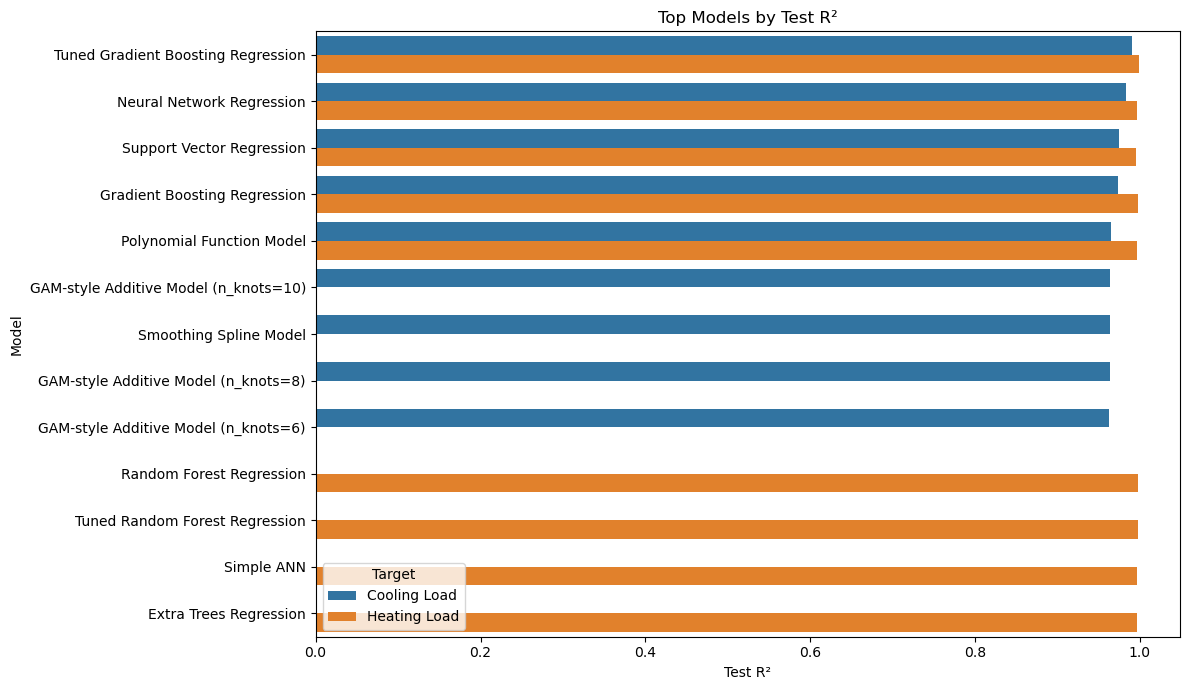

In [10]:
# ============================================================
# 10. TOP MODEL COMPARISON BY TEST R2
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Test_R2",
    y="Model",
    hue="Target"
)

plt.title("Top Models by Test R²")
plt.xlabel("Test R²")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

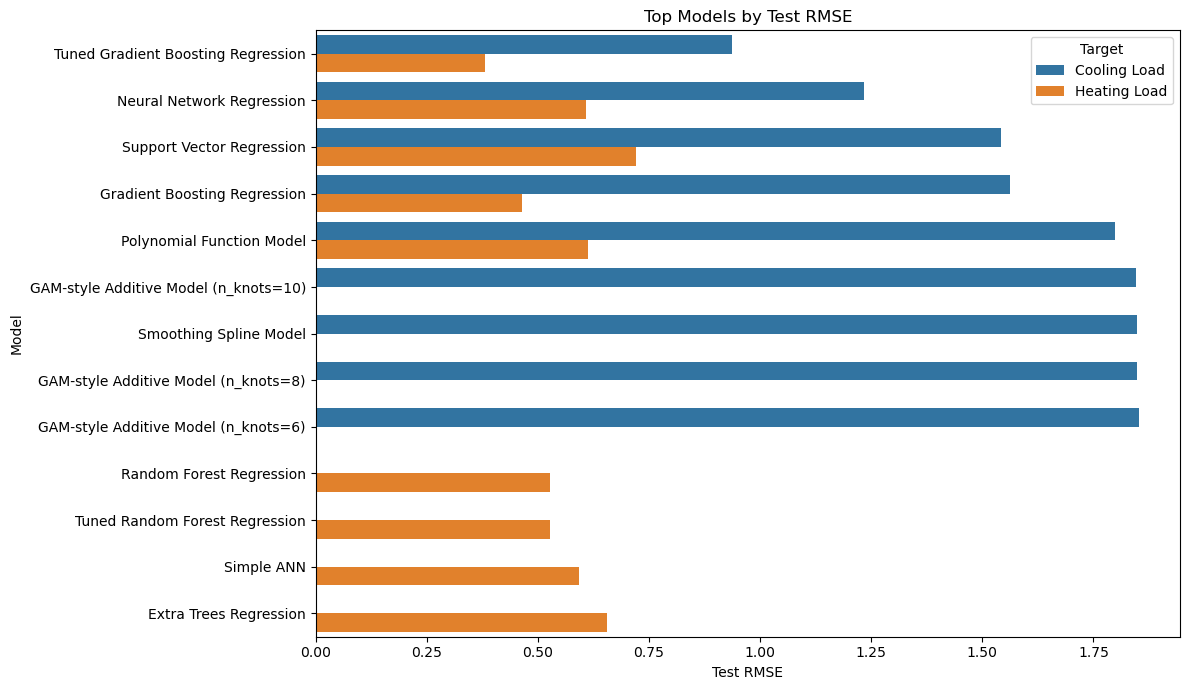

In [11]:
# ============================================================
# 11. TOP MODEL COMPARISON BY RMSE
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Test_RMSE",
    y="Model",
    hue="Target"
)

plt.title("Top Models by Test RMSE")
plt.xlabel("Test RMSE")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

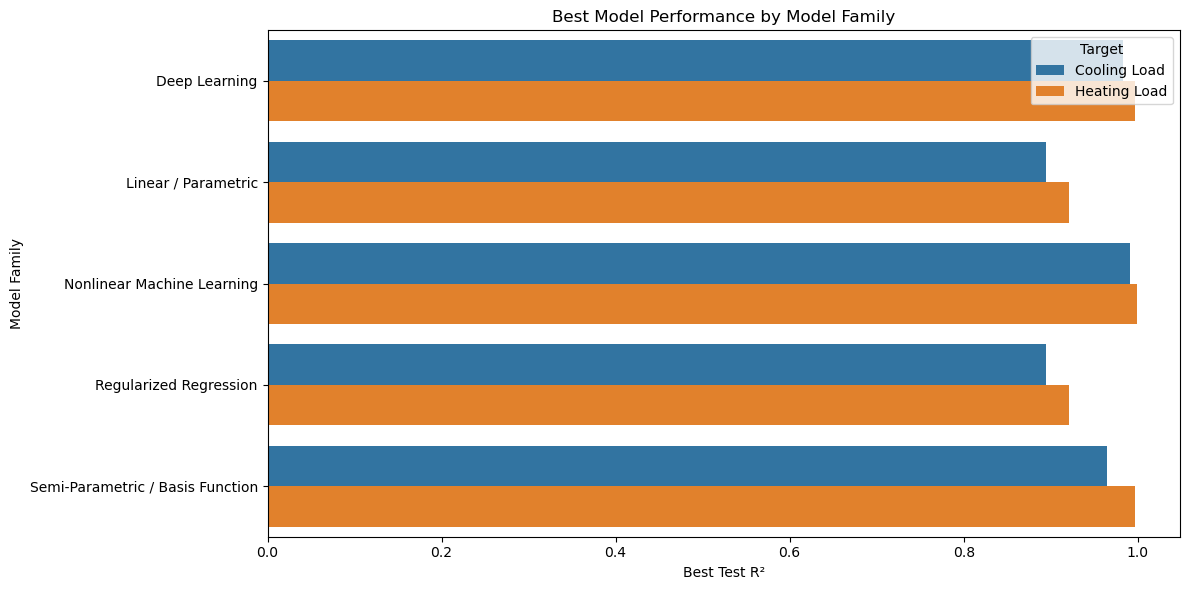

In [12]:
# ============================================================
# 12. MODEL FAMILY COMPARISON
# ============================================================

plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_by_family,
    x="Test_R2",
    y="Model_Family",
    hue="Target"
)

plt.title("Best Model Performance by Model Family")
plt.xlabel("Best Test R²")
plt.ylabel("Model Family")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

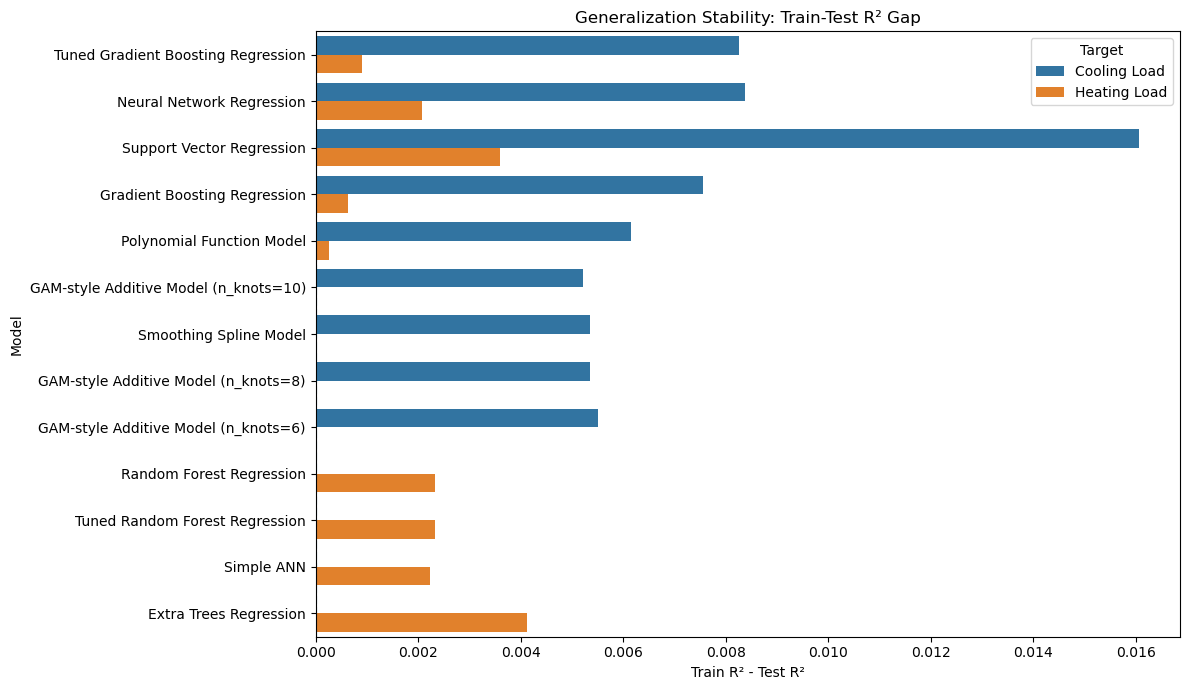

In [13]:
# ============================================================
# 13. GENERALIZATION GAP ANALYSIS
# ============================================================

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_models,
    x="Train_Test_R2_Gap",
    y="Model",
    hue="Target"
)

plt.axvline(0, linestyle="--")
plt.title("Generalization Stability: Train-Test R² Gap")
plt.xlabel("Train R² - Test R²")
plt.ylabel("Model")
plt.legend(title="Target")
plt.tight_layout()
plt.show()

# 5. Feature Importance Interpretation

Permutation importance results from the tuned Gradient Boosting models are loaded where available. These help translate the final model into practical building-design insights.

In [14]:
# ============================================================
# 14. LOAD FEATURE IMPORTANCE FILES
# ============================================================

importance_file_options = {
    "Heating Load": [
        "heating_gradient_boosting_permutation_importance.csv",
        "heating_gb_permutation_importance.csv"
    ],
    "Cooling Load": [
        "cooling_gradient_boosting_permutation_importance.csv",
        "cooling_gb_permutation_importance.csv"
    ]
}

importance_results = {}

for target, file_names in importance_file_options.items():
    for file_name in file_names:
        file_path = MODEL_OUTPUT_DIR / file_name

        if file_path.exists():
            importance_results[target] = pd.read_csv(file_path)
            print(f"Loaded {target} importance file: {file_name}")
            break

    if target not in importance_results:
        print(f"No importance file found for {target}")

for target, imp_df in importance_results.items():
    print(f"\n{target} Feature Importance")
    display(imp_df)

Loaded Heating Load importance file: heating_gradient_boosting_permutation_importance.csv
Loaded Cooling Load importance file: cooling_gradient_boosting_permutation_importance.csv

Heating Load Feature Importance


,Feature,Importance_Mean,Importance_STD
0,roof_area,3.985088,0.200209
1,overall_height,3.936159,0.190514
2,glazing_area,3.793693,0.193657
3,relative_compactness,3.534643,0.163461
4,surface_area,1.589329,0.077526
5,wall_area,1.576494,0.093507
6,glazing_area_distribution,0.200310,0.024146
7,orientation,0.123339,0.023062



Cooling Load Feature Importance


,Feature,Importance_Mean,Importance_STD
0,surface_area,4.306056,0.194253
1,overall_height,3.750698,0.181928
2,glazing_area,2.163570,0.133223
3,wall_area,1.618493,0.139192
4,relative_compactness,1.346027,0.091025
5,glazing_area_distribution,1.234347,0.108533
6,orientation,1.170464,0.115174
7,roof_area,0.841517,0.073137


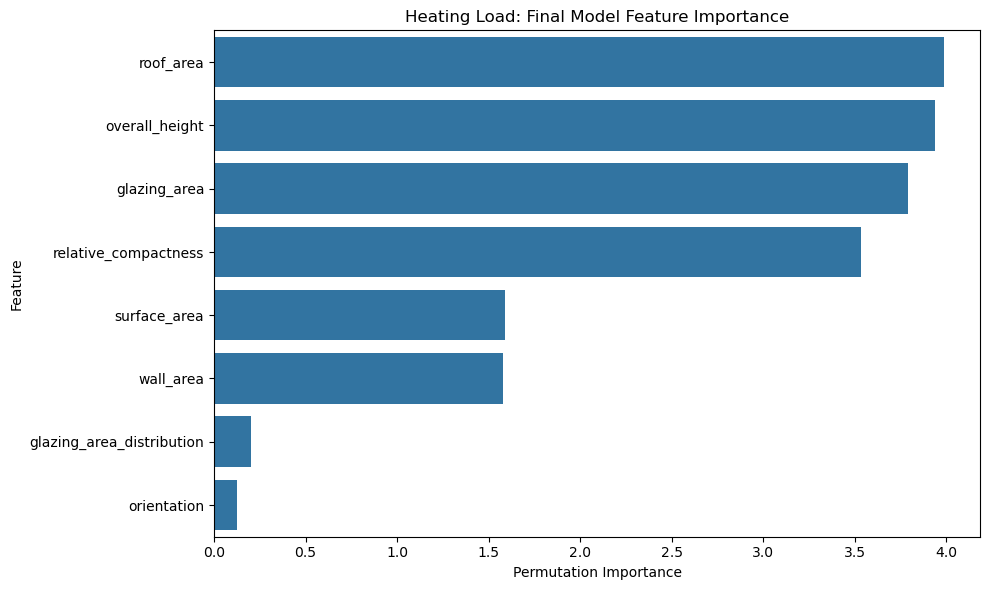

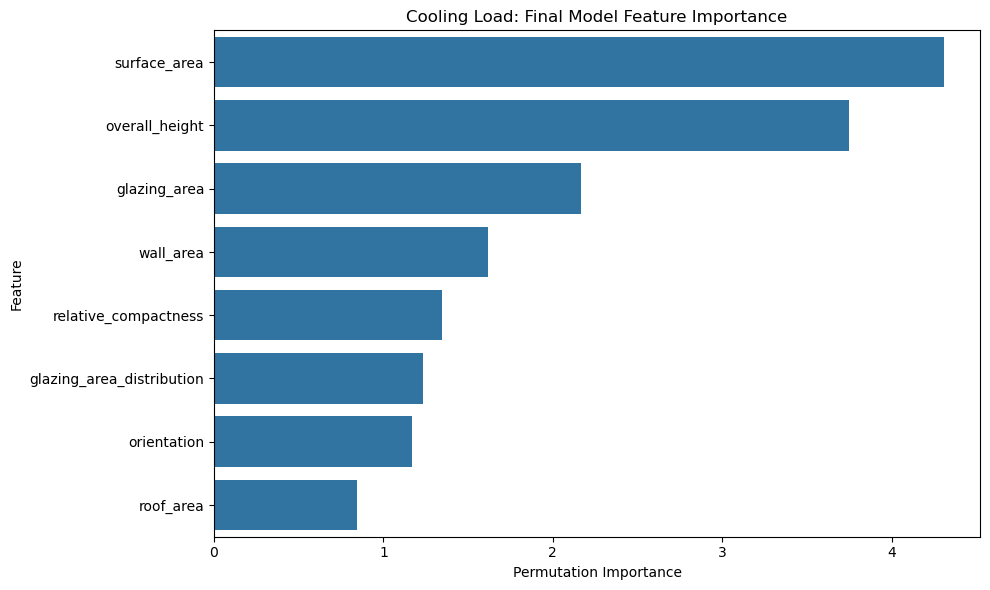

In [15]:
# ============================================================
# 15. FEATURE IMPORTANCE PLOTS
# ============================================================

for target, imp_df in importance_results.items():
    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=imp_df.sort_values("Importance_Mean", ascending=False),
        x="Importance_Mean",
        y="Feature"
    )

    plt.title(f"{target}: Final Model Feature Importance")
    plt.xlabel("Permutation Importance")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

# 6. Final Model Recommendation

The final model is selected using the following criteria:

1. Highest test \(R^2\)
2. Lowest RMSE and MAE
3. Strong generalization performance
4. Consistency across both response variables
5. Practical usefulness for building energy load prediction

In [16]:
# ============================================================
# 16. FINAL MODEL RECOMMENDATION TABLE
# ============================================================

final_recommendations = best_models.copy()

final_recommendations["Decision"] = np.where(
    final_recommendations["Train_Test_R2_Gap"].abs() <= 0.02,
    "Recommended: strong accuracy and stable generalization",
    "Review: possible overfitting risk"
)

display(final_recommendations)

,Target,Model,No_of_Features,Train_R2,Train_Adjusted_R2,Test_R2,Test_Adjusted_R2,Test_RMSE,Test_MAE,Test_MAPE_percent,AIC,BIC,Source_Notebook,Train_Test_R2_Gap,Rank,Decision
0,Cooling Load,Tuned Gradient Boosting Regression,NaN,0.998809,NaN,0.990551,0.990030,0.935678,0.562829,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.008258,1,Recommended: strong accuracy and stable genera...
1,Heating Load,Tuned Gradient Boosting Regression,NaN,0.999499,NaN,0.998602,0.998525,0.381722,0.275321,NaN,NaN,NaN,Semi-Parametric and Nonlinear,0.000897,1,Recommended: strong accuracy and stable genera...


In [17]:
# ============================================================
# 17. PRINT FINAL MODEL SUMMARY
# ============================================================

for _, row in final_recommendations.iterrows():
    print("=" * 70)
    print(f"Target: {row['Target']}")
    print(f"Recommended Model: {row['Model']}")
    print(f"Test R²: {row['Test_R2']:.4f}")
    print(f"Adjusted Test R²: {row['Test_Adjusted_R2']:.4f}")
    print(f"RMSE: {row['Test_RMSE']:.4f}")
    print(f"MAE: {row['Test_MAE']:.4f}")
    print(f"Train-Test R² Gap: {row['Train_Test_R2_Gap']:.4f}")
    print("=" * 70)

Target: Cooling Load
Recommended Model: Tuned Gradient Boosting Regression
Test R²: 0.9906
Adjusted Test R²: 0.9900
RMSE: 0.9357
MAE: 0.5628
Train-Test R² Gap: 0.0083
Target: Heating Load
Recommended Model: Tuned Gradient Boosting Regression
Test R²: 0.9986
Adjusted Test R²: 0.9985
RMSE: 0.3817
MAE: 0.2753
Train-Test R² Gap: 0.0009


# 7. Final Project Conclusion

The full modeling workflow systematically evaluated linear, regularized, semi-parametric, nonlinear machine learning, and deep learning approaches for predicting building energy loads. The results consistently show that nonlinear models substantially outperform classical linear methods, confirming the presence of complex nonlinear relationships between building design characteristics and energy demand.

Among all models considered, **Tuned Gradient Boosting Regression** achieved the strongest overall predictive performance for both Heating Load and Cooling Load while maintaining strong generalization performance. Feature importance analysis further showed that building geometry and envelope-related variables such as Surface Area, Roof Area, Overall Height, Relative Compactness, and Glazing Area are the dominant drivers of energy demand. Therefore, Tuned Gradient Boosting Regression is recommended as the final predictive model for both response variables.

## Report-Ready Five-Line Summary

This study evaluated statistical, regularized, semi-parametric, nonlinear machine learning, and deep learning models for predicting building Heating Load and Cooling Load.  
The results showed that nonlinear approaches substantially outperformed linear and regularized models, confirming the presence of complex nonlinear relationships in the data.  
Among all models, **Tuned Gradient Boosting Regression** achieved the best performance for both Heating Load and Cooling Load, with the highest test \(R^2\) and lowest prediction errors.  
Feature importance analysis identified **Surface Area, Roof Area, Overall Height, Relative Compactness, and Glazing Area** as the most influential determinants of building energy demand.  
Overall, Tuned Gradient Boosting Regression is recommended as the final model due to its superior accuracy, robustness, and generalization performance.

In [18]:
# ============================================================
# 18. SAVE FINAL OUTPUTS
# ============================================================

master_comparison.to_csv(
    FINAL_OUTPUT_DIR / "master_model_comparison.csv",
    index=False
)

ranked_models.to_csv(
    FINAL_OUTPUT_DIR / "ranked_model_results.csv",
    index=False
)

top_models.to_csv(
    FINAL_OUTPUT_DIR / "top_models_by_target.csv",
    index=False
)

best_models.to_csv(
    FINAL_OUTPUT_DIR / "best_models_by_target.csv",
    index=False
)

best_by_family.to_csv(
    FINAL_OUTPUT_DIR / "best_models_by_family.csv",
    index=False
)

final_recommendations.to_csv(
    FINAL_OUTPUT_DIR / "final_model_recommendations.csv",
    index=False
)

print("Final model-selection outputs saved successfully.")
print("Saved to:", FINAL_OUTPUT_DIR.resolve())

Final model-selection outputs saved successfully.
Saved to: C:\Users\admin\Desktop\pppp lab\group-work\full\outputs\final_selection


# Final Project Conclusion

This study successfully developed and evaluated a comprehensive range of predictive models for estimating **Heating Load (Y1)** and **Cooling Load (Y2)** using the eight building design characteristics provided in the Energy Efficiency dataset. The analysis began with extensive exploratory data analysis and baseline linear regression modeling before progressing through optimized parametric models, regularized regression techniques, semi-parametric methods, nonlinear machine learning algorithms, and deep learning approaches. This systematic workflow enabled both predictive assessment and methodological comparison across multiple modeling paradigms.

The exploratory analysis revealed strong relationships between the building characteristics and energy demand, with particularly important contributions from **Surface Area, Roof Area, Overall Height, Relative Compactness, Wall Area, and Glazing Area**. Correlation analysis, multicollinearity diagnostics, and model assumption testing demonstrated that although linear regression provided a reasonable baseline, important nonlinear relationships existed within the data. This finding was supported by the Ramsey RESET tests and by the substantial improvements observed when nonlinear methods were introduced.

The optimized parametric and regularized regression models achieved strong predictive performance, explaining approximately 89–92% of the variation in Cooling Load and 92–93% of the variation in Heating Load. However, the semi-parametric models, including polynomial regression, regression splines, smoothing splines, and Generalized Additive Models (GAMs), produced substantial performance improvements, confirming that the relationship between building design features and energy requirements is not purely linear. These models demonstrated that flexible functional forms are better suited for capturing the complex behavior of building energy consumption.

The highest predictive accuracy was achieved by the nonlinear machine learning models. In particular, **Tuned Gradient Boosting Regression** emerged as the best-performing model for both response variables, achieving a test \(R^2\) of **0.9986** for Heating Load and **0.9906** for Cooling Load, together with the lowest prediction errors and excellent generalization performance. Deep learning models also performed exceptionally well and confirmed the presence of strong nonlinear patterns, but they did not surpass the performance of the tuned Gradient Boosting models on this relatively small tabular dataset.

Feature importance analysis showed that **Surface Area, Overall Height, Roof Area, Relative Compactness, and Glazing Area** are the most influential determinants of building energy demand. These findings are consistent with engineering principles because building geometry, compactness, envelope dimensions, and glazing characteristics directly influence heat transfer, thermal retention, and cooling requirements. Consequently, these variables should receive primary consideration during building design when the objective is to improve energy efficiency.

Overall, the study demonstrates that advanced nonlinear learning methods provide the most accurate and reliable framework for predicting building Heating Load and Cooling Load requirements. Among all models evaluated, **Tuned Gradient Boosting Regression is recommended as the final model for both targets due to its superior predictive accuracy, robustness, and generalization performance**. The results further show that incorporating nonlinear modeling techniques is essential for accurately capturing the complex interactions between building characteristics and energy consumption, thereby providing valuable insights for energy-efficient building design and decision-making.